# Greek Sensitivity Engine

In [55]:
# Required Libraries

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.stats import norm


## BSM Pricing Formula

The generalised Black-Scholes-Merton price with continuous dividend yield $q$:

$$C = Se^{-qT}N(d_1) - Ke^{-rT}N(d_2)$$

$$P = Ke^{-rT}N(-d_2) - Se^{-qT}N(-d_1)$$

Where:

$$d_1 = \frac{\ln(S/K) + (r - q + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}$$

$$d_2 = d_1 - \sigma\sqrt{T}$$

| Symbol | Description |
|--------|-------------|
| $S$ | Spot price |
| $K$ | Strike price |
| $T$ | Time to expiry in years |
| $r$ | Risk-free rate, continuously compounded |
| $q$ | Continuous dividend yield |
| $\sigma$ | Implied volatility |
| $N(\cdot)$ | Standard normal CDF |
| $n(\cdot)$ | Standard normal PDF |

In [56]:
# Black Scholes Function

def bsm_price(S, K, T, r, q, sigma, option_type="call"):
    if np.any(T <= 0):
        intrinsic = np.where(
            option_type == "call",
            np.maximum(S - K, 0),
            np.maximum(K - S, 0)
        )
        return intrinsic

    d1 = (np.log(S/K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        price = (S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2))
    else:
        price = (K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1))

    return price


In [41]:
# Sanity check 

test_price = bsm_price(S=500, K=500, T=0.25, r=0.05, q=0.013, sigma=0.20, option_type="call")
print(f"ATM Call Price:  {test_price:.4f}")

# Put-call parity: C - P = S*exp(-qT) - K*exp(-rT)
C = bsm_price(500, 500, 0.25, 0.05, 0.013, 0.20, "call")
P = bsm_price(500, 500, 0.25, 0.05, 0.013, 0.20, "put")
pcp_lhs = C - P
pcp_rhs = 500 * np.exp(-0.013 * 0.25) - 500 * np.exp(-0.05 * 0.25)
print(f"Put-Call Parity error: {abs(pcp_lhs - pcp_rhs):.2e}")  

ATM Call Price:  22.1615
Put-Call Parity error: 8.53e-14


In [42]:
def _d1_d2(S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

## Greeks

### First-Order Greeks

**Delta** — sensitivity of option price to a $1 move in spot:

$$\Delta_{call} = e^{-qT}N(d_1)$$

$$\Delta_{put} = e^{-qT}(N(d_1) - 1)$$

**Vega** — sensitivity to a 1 vol point change in implied volatility
(identical for calls and puts):

$$\mathcal{V} = \frac{Se^{-qT}n(d_1)\sqrt{T}}{100}$$

**Theta** — daily time decay:

$$\Theta_{call} = \frac{-Se^{-qT}n(d_1)\sigma}{2\sqrt{T}} - rKe^{-rT}N(d_2) + qSe^{-qT}N(d_1)$$

$$\Theta_{put} = \frac{-Se^{-qT}n(d_1)\sigma}{2\sqrt{T}} + rKe^{-rT}N(-d_2) - qSe^{-qT}N(-d_1)$$

Divided by 365 to express as calendar day decay.

**Rho** — sensitivity to a 1bp change in interest rates:

$$\rho_{call} = \frac{KTe^{-rT}N(d_2)}{100}$$

$$\rho_{put} = \frac{-KTe^{-rT}N(-d_2)}{100}$$

In [43]:
# First Order Greeks
def delta(S, K, T, r, q, sigma, option_type="call"):
    d1, d2 = _d1_d2(S, K, T, r, q, sigma)
    if option_type == "call":
        return np.exp(-q * T) * norm.cdf(d1)
    else:
        return np.exp(-q * T) * (norm.cdf(d1) - 1)


def vega(S, K, T, r, q, sigma):
    # Identical for calls and puts — follows from put-call parity
    d1, d2 = _d1_d2(S, K, T, r, q, sigma)
    return S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T) / 100  # per 1 vol point

def theta(S, K, T, r, q, sigma, option_type="call"):
    d1, d2 = _d1_d2(S, K, T, r, q, sigma)
    decay = -(S * np.exp(-q * T) * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))

    if option_type == "call":
        return (decay
                - r * K * np.exp(-r * T) * norm.cdf(d2)
                + q * S * np.exp(-q * T) * norm.cdf(d1)) / 365
    else:
        return (decay
                + r * K * np.exp(-r * T) * norm.cdf(-d2)
                - q * S * np.exp(-q * T) * norm.cdf(-d1)) / 365


def rho(S, K, T, r, q, sigma, option_type="call"):
    d1, d2 = _d1_d2(S, K, T, r, q, sigma)
    if option_type == "call":
        return K * T * np.exp(-r * T) * norm.cdf(d2) / 100
    else:
        return -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100


### Second-Order Greeks

**Gamma** — rate of change of delta, identical for calls and puts:

$$\Gamma = \frac{e^{-qT}n(d_1)}{S\sigma\sqrt{T}}$$

Highest at ATM and near expiry. The "gamma trap" for short-dated options sellers.

**Vanna** — $\partial\Delta/\partial\sigma = \partial\mathcal{V}/\partial S$,
cross-sensitivity of delta to volatility:

$$\text{Vanna} = -e^{-qT}n(d_1)\frac{d_2}{\sigma}$$

Changes sign across ATM — positive for OTM calls, negative for OTM puts.
Explains why delta hedges behave asymmetrically when spot and vol move together.

**Volga** — $\partial\mathcal{V}/\partial\sigma$,
sensitivity of vega to volatility:

$$\text{Volga} = \mathcal{V} \cdot \frac{d_1 d_2}{\sigma}$$

Always positive for long options. Largest in the wings — long-dated OTM
options gain disproportionately during volatility-of-volatility spikes.

**Charm** — $\partial\Delta/\partial T$, delta decay per calendar day:

$$\text{Charm}_{call} = qe^{-qT}N(d_1) - e^{-qT}n(d_1)\frac{2(r-q)T - d_2\sigma\sqrt{T}}{2T\sigma\sqrt{T}}$$

$$\text{Charm}_{put} = -qe^{-qT}N(-d_1) - e^{-qT}n(d_1)\frac{2(r-q)T - d_2\sigma\sqrt{T}}{2T\sigma\sqrt{T}}$$

Explains why static delta hedges go stale even without spot moves — delta drifts through time independently of price action.

In [44]:
#Second Order Greeks

def gamma(S, K, T, r, q, sigma):
    # Identical for calls and puts
    d1, d2 = _d1_d2(S, K, T, r, q, sigma)
    return np.exp(-q * T) * norm.pdf(d1) / (S * sigma * np.sqrt(T))


def vanna(S, K, T, r, q, sigma):
    # dDelta/dSigma = dVega/dS
    # Changes sign across ATM — positive OTM call side, negative OTM put side
    d1, d2 = _d1_d2(S, K, T, r, q, sigma)
    return -np.exp(-q * T) * norm.pdf(d1) * d2 / sigma

def volga(S, K, T, r, q, sigma):
    # dVega/dSigma — always positive for long options
    d1, d2 = _d1_d2(S, K, T, r, q, sigma)
    return vega(S, K, T, r, q, sigma) * d1 * d2 / sigma


def charm(S, K, T, r, q, sigma, option_type="call"):
    d1, d2 = _d1_d2(S, K, T, r, q, sigma)

    common = np.exp(-q * T) * norm.pdf(d1) * (2 * (r - q) * T - d2 * sigma * np.sqrt(T)) / (2 * T * sigma * np.sqrt(T))

    if option_type == "call":
        return q * np.exp(-q * T) * norm.cdf(d1) - common
    else:
        return -q * np.exp(-q * T) * norm.cdf(-d1) - common



In [45]:
S, K, T, r, q, sigma = 500, 500, 0.25, 0.05, 0.013, 0.20

print("── First Order ──────────────────────────")
print(f"Delta  (call):  {delta(S, K, T, r, q, sigma, 'call'):.4f}   # expect ~0.55")
print(f"Delta  (put):   {delta(S, K, T, r, q, sigma, 'put'):.4f}   # expect ~-0.44")
print(f"Vega:           {vega(S, K, T, r, q, sigma):.4f}            # per 1 vol point")
print(f"Theta  (call):  {theta(S, K, T, r, q, sigma, 'call'):.4f}  # expect negative")
print(f"Rho    (call):  {rho(S, K, T, r, q, sigma, 'call'):.4f}")

print("\n── Second Order ─────────────────────────")
print(f"Gamma:          {gamma(S, K, T, r, q, sigma):.6f}           # expect positive")
print(f"Vanna:          {vanna(S, K, T, r, q, sigma):.6f}           # expect near zero ATM")
print(f"Volga:          {volga(S, K, T, r, q, sigma):.6f}           # expect positive")
print(f"Charm  (call):  {charm(S, K, T, r, q, sigma, 'call'):.6f}")

print("\n── Relationships ────────────────────────")
dc = delta(S, K, T, r, q, sigma, "call")
dp = delta(S, K, T, r, q, sigma, "put")
print(f"Call delta - Put delta:  {dc - dp:.6f}  |  exp(-qT): {np.exp(-q*T):.6f}  # should match")

── First Order ──────────────────────────
Delta  (call):  0.5549   # expect ~0.55
Delta  (put):   -0.4419   # expect ~-0.44
Vega:           0.9841            # per 1 vol point
Theta  (call):  -0.1329  # expect negative
Rho    (call):  0.6382

── Second Order ─────────────────────────
Gamma:          0.007873           # expect positive
Vanna:          -0.083647           # expect near zero ATM
Volga:          0.029799           # expect positive
Charm  (call):  -0.104972

── Relationships ────────────────────────
Call delta - Put delta:  0.996755  |  exp(-qT): 0.996755  # should match


In [46]:
spots   = np.linspace(400, 600, 50)
expiries = np.linspace(0.02, 1.0, 50)

S_grid, T_grid = np.meshgrid(spots, expiries)

gamma_surface = gamma(S_grid, K=500, T=T_grid, r=0.05, q=0.013, sigma=0.20)
vanna_surface = vanna(S_grid, K=500, T=T_grid, r=0.05, q=0.013, sigma=0.20)
delta_surface = delta(S_grid, K=500, T=T_grid, r=0.05, q=0.013, sigma=0.20)

print(f"Grid shape:         {S_grid.shape}")
print(f"Gamma surface shape: {gamma_surface.shape}")
print(f"Gamma min/max:      {gamma_surface.min():.6f} → {gamma_surface.max():.6f}")
print(f"Vanna has negatives: {(vanna_surface < 0).any()}") 

Grid shape:         (50, 50)
Gamma surface shape: (50, 50)
Gamma min/max:      0.000000 → 0.028164
Vanna has negatives: True


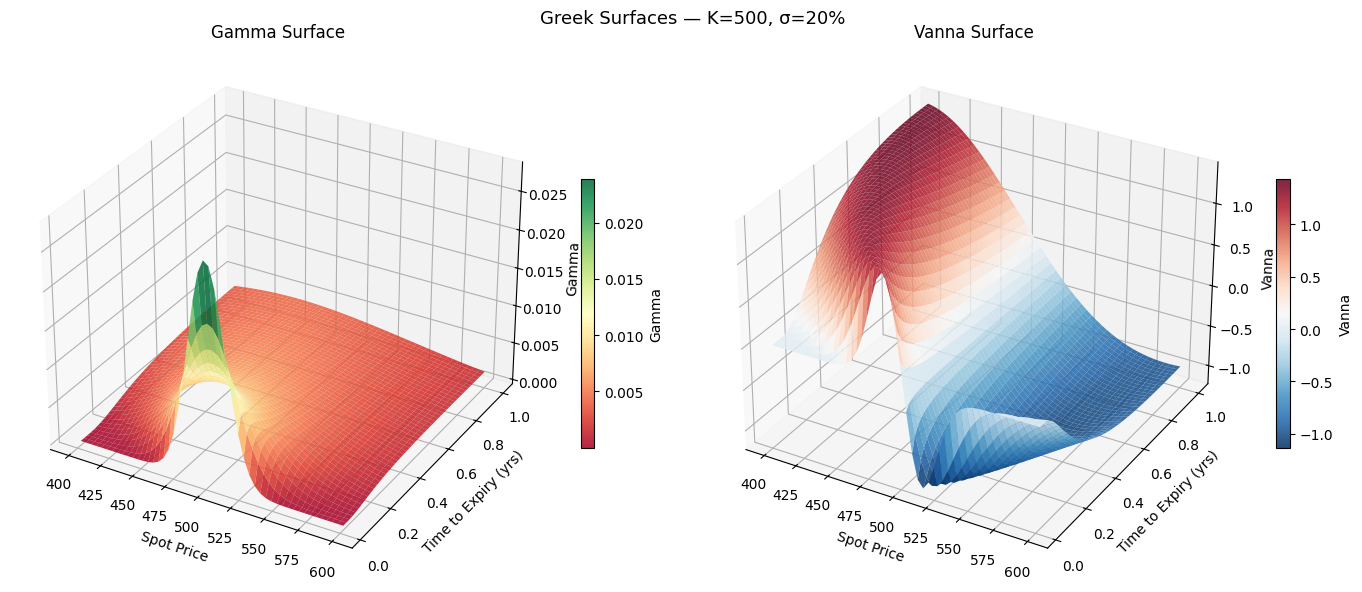

In [47]:
fig = plt.figure(figsize=(14, 6))

# ── Gamma Surface ─────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(S_grid, T_grid, gamma_surface, 
                          cmap='RdYlGn', alpha=0.85)
fig.colorbar(surf1, ax=ax1, shrink=0.5, label='Gamma')
ax1.set_xlabel('Spot Price')
ax1.set_ylabel('Time to Expiry (yrs)')
ax1.set_zlabel('Gamma')
ax1.set_title('Gamma Surface')
ax1.view_init(elev=30, azim=-60)

# ── Vanna Surface ─────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(S_grid, T_grid, vanna_surface,
                          cmap='RdBu_r', alpha=0.85)
fig.colorbar(surf2, ax=ax2, shrink=0.5, label='Vanna')
ax2.set_xlabel('Spot Price')
ax2.set_ylabel('Time to Expiry (yrs)')
ax2.set_zlabel('Vanna')
ax2.set_title('Vanna Surface')
ax2.view_init(elev=30, azim=-60)

plt.suptitle('Greek Surfaces — K=500, σ=20%', fontsize=13)
plt.tight_layout()
plt.savefig('gamma_vanna_surfaces.png', dpi=150, bbox_inches='tight')
plt.show()

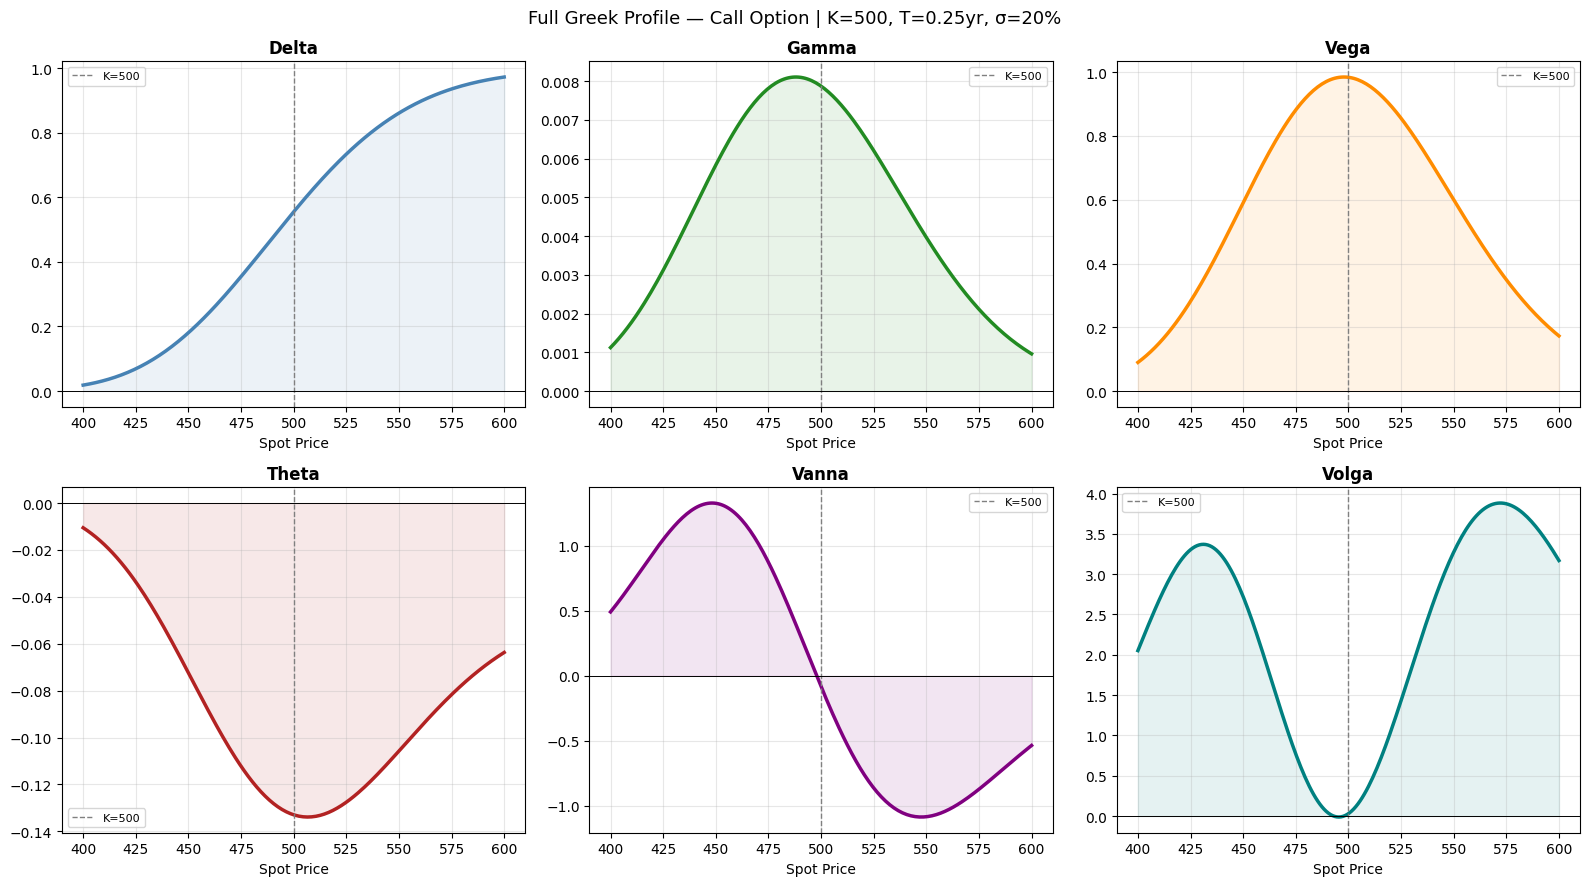

In [48]:
spots = np.linspace(400, 600, 200)
K, T, r, q, sigma = 500, 0.25, 0.05, 0.013, 0.20

greeks = {
    "Delta":  delta(spots, K, T, r, q, sigma, "call"),
    "Gamma":  gamma(spots, K, T, r, q, sigma),
    "Vega":   vega(spots,  K, T, r, q, sigma),
    "Theta":  theta(spots, K, T, r, q, sigma, "call"),
    "Vanna":  vanna(spots, K, T, r, q, sigma),
    "Volga":  volga(spots, K, T, r, q, sigma),
}
colors = ["steelblue", "forestgreen", "darkorange", 
          "firebrick", "purple", "teal"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (name, values), color in zip(axes, greeks.items(), colors):
    ax.plot(spots, values, lw=2.5, color=color)
    ax.fill_between(spots, 0, values, alpha=0.10, color=color)
    ax.axvline(K, color="grey", linestyle="--", lw=1, label=f"K={K}")
    ax.axhline(0, color="black", lw=0.7)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Spot Price")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle(f"Full Greek Profile — Call Option | K={K}, T={T}yr, σ={sigma:.0%}", 
             fontsize=13)
plt.tight_layout()
plt.savefig("greek_profile_panel.png", dpi=150, bbox_inches="tight")
plt.show()

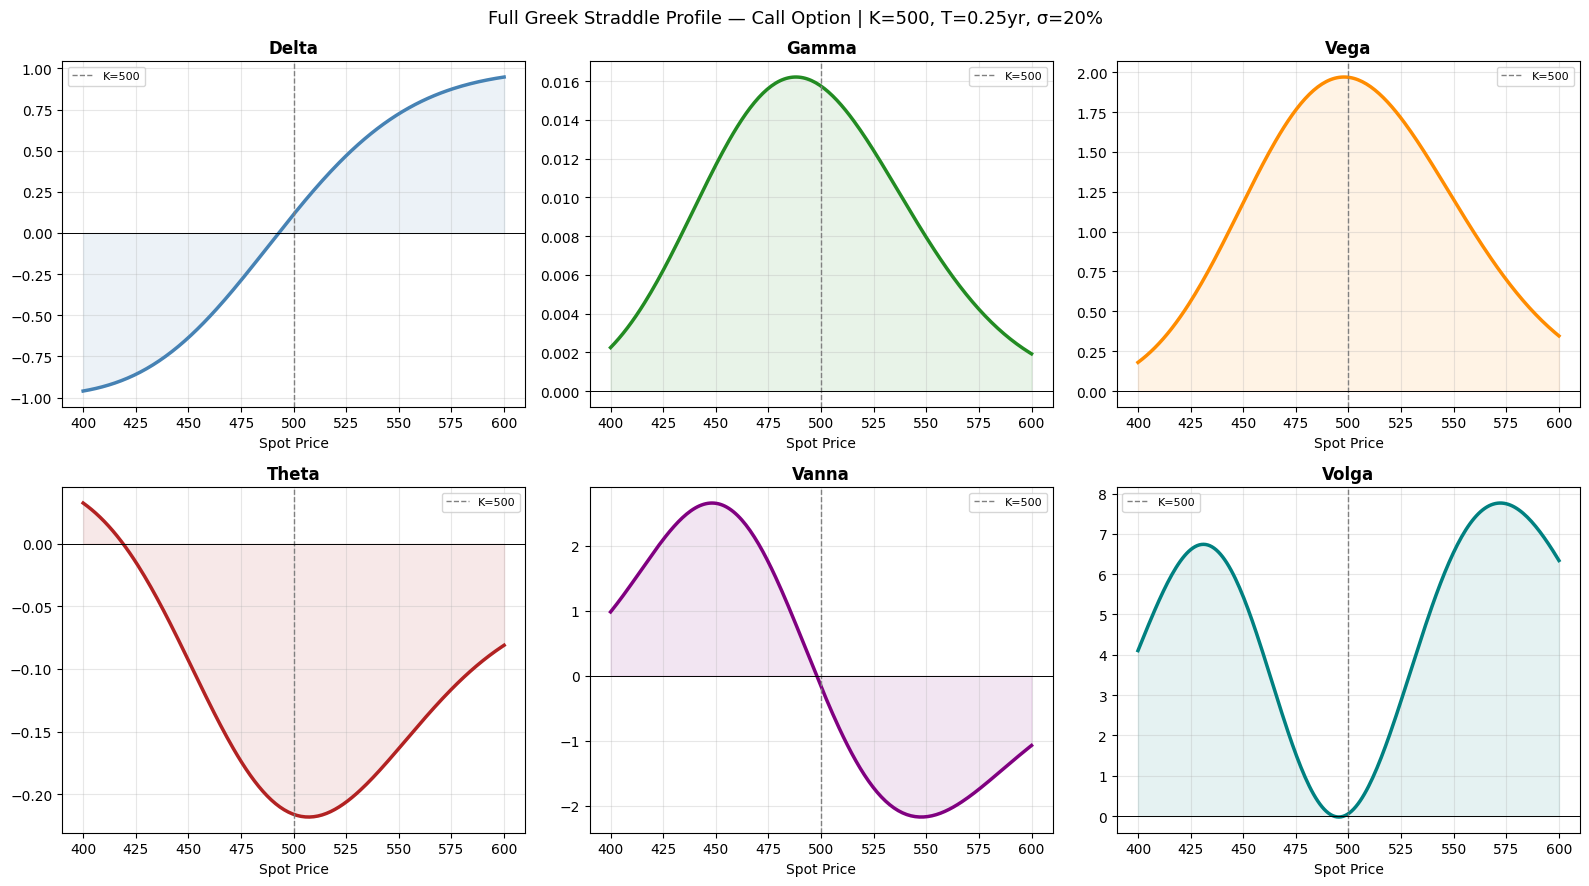

In [49]:
spots = np.linspace(400, 600, 200)
K, T, r, q, sigma = 500, 0.25, 0.05, 0.013, 0.20

greeks_straddle = {
    "Delta": delta(spots, K, T, r, q, sigma, "call") + delta(spots, K, T, r, q, sigma, "put"),
    "Gamma": gamma(spots, K, T, r, q, sigma) * 2,
    "Vega":  vega(spots, K, T, r, q, sigma) * 2,
    "Theta": theta(spots, K, T, r, q, sigma, "call") + theta(spots, K, T, r, q, sigma, "put"),
    "Vanna": vanna(spots, K, T, r, q, sigma) * 2,
    "Volga": volga(spots, K, T, r, q, sigma) * 2,
}
colors = ["steelblue", "forestgreen", "darkorange", 
          "firebrick", "purple", "teal"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (name, values), color in zip(axes, greeks_straddle.items(), colors):
    ax.plot(spots, values, lw=2.5, color=color)
    ax.fill_between(spots, 0, values, alpha=0.10, color=color)
    ax.axvline(K, color="grey", linestyle="--", lw=1, label=f"K={K}")
    ax.axhline(0, color="black", lw=0.7)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Spot Price")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle(f"Full Greek Straddle Profile — Call Option | K={K}, T={T}yr, σ={sigma:.0%}", 
             fontsize=13)
plt.tight_layout()
plt.savefig("greekstradle_profile_panel.png", dpi=150, bbox_inches="tight")
plt.show()

In [50]:
def implied_vol(market_price, S, K, T, r, q, option_type="call", 
                tol=1e-6, max_iter=100):
    """
    Newton-Raphson solver: finds the sigma that makes BSM price = market price.
    Returns np.nan if it fails to converge.
    """
    # Initial guess — simple approximation
    sigma = np.sqrt(2 * np.pi / T) * market_price / S

    for _ in range(max_iter):
        price = bsm_price(S, K, T, r, q, sigma, option_type)
        v     = vega(S, K, T, r, q, sigma) * 100    # undo the /100 scaling
        
        if abs(v) < 1e-10:      # vega too small — solver unstable
            return np.nan
        
        sigma -= (price - market_price) / v          # Newton-Raphson update
        
        if sigma <= 0:
            return np.nan
        
        if abs(price - market_price) < tol:
            break

    return float(sigma)

In [51]:
# Round-trip: price → implied vol → reprice
S, K, T, r, q, sigma = 500, 500, 0.25, 0.05, 0.013, 0.20

market_price = bsm_price(S, K, T, r, q, sigma, "call")
solved_iv    = implied_vol(market_price, S, K, T, r, q, "call")
recovered    = bsm_price(S, K, T, r, q, solved_iv, "call")

print(f"Original sigma:   {sigma:.6f}")
print(f"Solved IV:        {solved_iv:.6f}")
print(f"Original price:   {market_price:.6f}")
print(f"Recovered price:  {recovered:.6f}")
print(f"Price error:      {abs(market_price - recovered):.2e}  # expect < 1e-6")

Original sigma:   0.200000
Solved IV:        0.200000
Original price:   22.161486
Recovered price:  22.161486
Price error:      0.00e+00  # expect < 1e-6


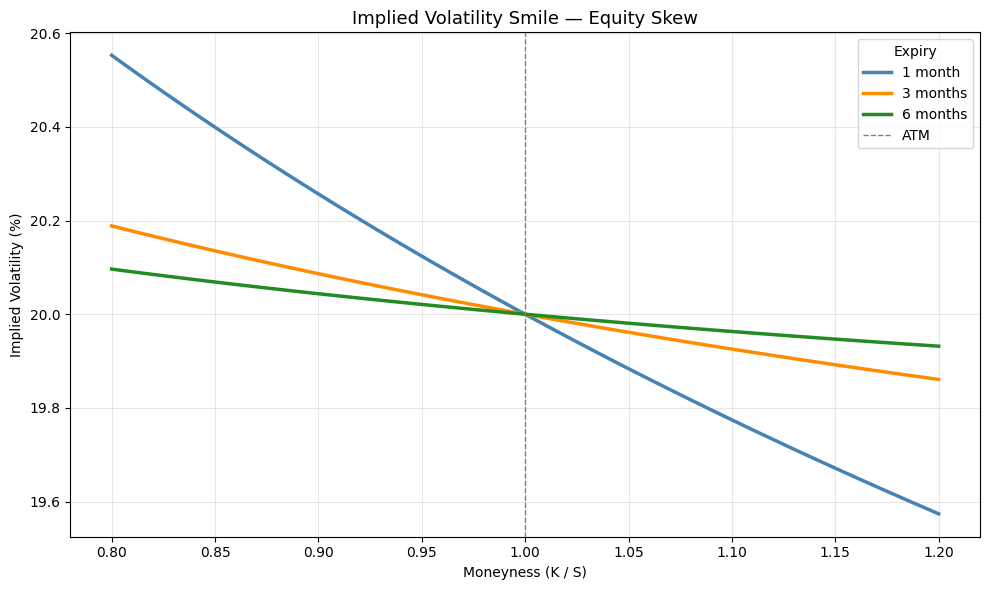

In [52]:
# ── Parametric smile — simple skew ───────────────────────────────────────────
strikes = np.linspace(400, 600, 100)
S, T, r, q = 500, 0.25, 0.05, 0.013
atm_vol = 0.20

def simple_skew(K, S, atm_vol, skew_slope=-0.002, convexity=0.0001):
    moneyness = np.log(K / S)    # 0 at ATM, negative for puts, positive for calls
    return atm_vol + skew_slope * moneyness + convexity * moneyness**2

# Generate smile across three expiries
expiry_labels = ["1 month", "3 months", "6 months"]
expiry_values = [1/12, 0.25, 0.50]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["steelblue", "darkorange", "forestgreen"]

for T_val, label, color in zip(expiry_values, expiry_labels, colors):
    smile = simple_skew(strikes, S, atm_vol,
                        skew_slope=-0.002 / T_val,        
                        convexity=0.001 / np.sqrt(T_val)) 
    ax.plot(strikes / S, smile * 100, lw=2.5, color=color, label=label)

ax.axvline(1.0, color="grey", linestyle="--", lw=1, label="ATM")
ax.set_xlabel("Moneyness (K / S)")
ax.set_ylabel("Implied Volatility (%)")
ax.set_title("Implied Volatility Smile — Equity Skew", fontsize=13)
ax.legend(title="Expiry")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("vol_smile.png", dpi=150, bbox_inches="tight")
plt.show()

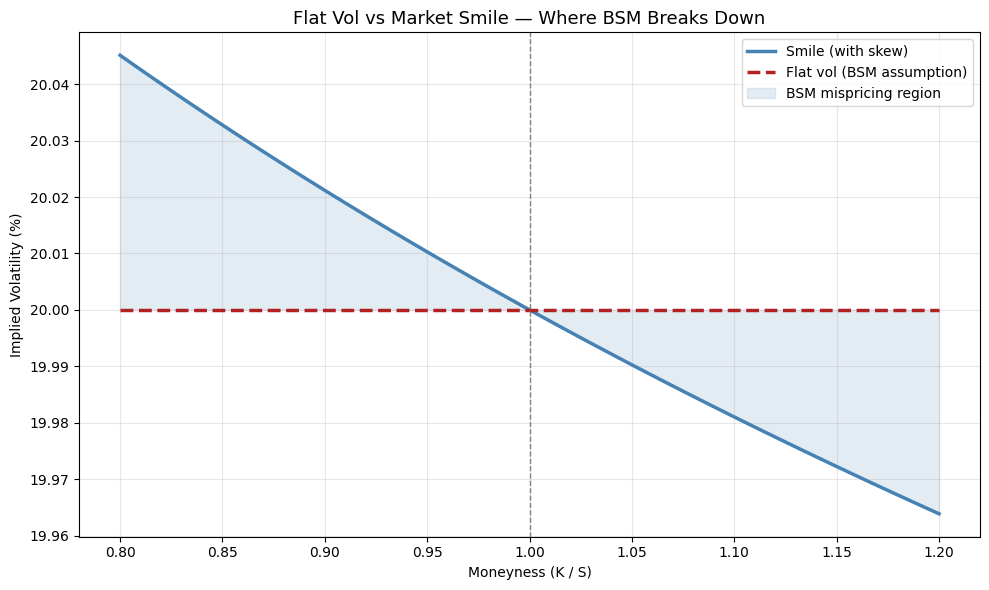

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))

smile    = simple_skew(strikes, S, atm_vol)
flat_vol = np.full_like(strikes, atm_vol)

ax.plot(strikes / S, smile * 100,    lw=2.5, color="steelblue", label="Smile (with skew)")
ax.plot(strikes / S, flat_vol * 100, lw=2.5, color="firebrick", 
        linestyle="--", label="Flat vol (BSM assumption)")
ax.fill_between(strikes / S, flat_vol * 100, smile * 100, 
                alpha=0.15, color="steelblue", label="BSM mispricing region")
ax.axvline(1.0, color="grey", linestyle="--", lw=1)
ax.set_xlabel("Moneyness (K / S)")
ax.set_ylabel("Implied Volatility (%)")
ax.set_title("Flat Vol vs Market Smile — Where BSM Breaks Down", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("flat_vs_smile.png", dpi=150, bbox_inches="tight")
plt.show()

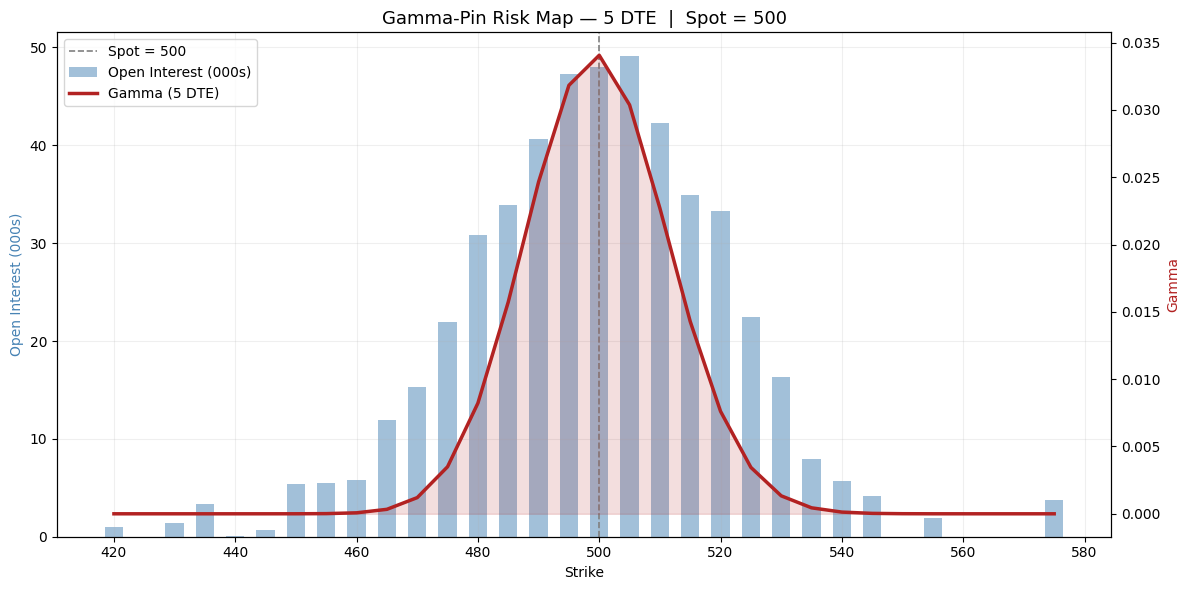

In [54]:
# ── Simulate open interest distribution across strikes ────────────────────────
np.random.seed(42)
strikes_pin = np.arange(420, 580, 5)   # round number strikes, 5-point spacing
S, K_pin, T_pin, r, q, sigma = 500, 500, 5/365, 0.05, 0.013, 0.20

# OI concentrated at round numbers, highest at ATM
oi = np.exp(-0.5 * ((strikes_pin - S) / 20) ** 2) * 50000
oi += np.random.normal(0, 2000, len(strikes_pin))   # add noise
oi = np.maximum(oi, 0)                               # no negative OI

# Gamma profile at 5 DTE — this is where pinning is active
gamma_pin = gamma(strikes_pin, K_pin, T_pin, r, q, sigma)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.bar(strikes_pin, oi / 1000, width=3, color="steelblue", 
        alpha=0.5, label="Open Interest (000s)")
ax2.plot(strikes_pin, gamma_pin, color="firebrick", 
         lw=2.5, label="Gamma (5 DTE)")
ax2.fill_between(strikes_pin, 0, gamma_pin, alpha=0.15, color="firebrick")

ax1.axvline(S, color="grey", linestyle="--", lw=1.2, label=f"Spot = {S}")
ax1.set_xlabel("Strike")
ax1.set_ylabel("Open Interest (000s)", color="steelblue")
ax2.set_ylabel("Gamma", color="firebrick")
ax1.set_title("Gamma-Pin Risk Map — 5 DTE  |  Spot = 500", fontsize=13)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("gamma_pin.png", dpi=150, bbox_inches="tight")
plt.show()